In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/MyDrive")

In [ ]:
!apt-get install unrar -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [ ]:
import tensorflow as tf

train = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/program/DATASET/train",
    image_size=(224,224),
    batch_size=32,
    label_mode='int',
    shuffle=True
)

val = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/program/DATASET/val",
    image_size=(224,224),
    batch_size=32,
    label_mode='int',
    shuffle=False
)

test = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/program/DATASET/test",
    image_size=(224,224),
    batch_size=32,
    label_mode='int',
    shuffle=False
)

Found 5387 files belonging to 3 classes.
Found 1349 files belonging to 3 classes.
Found 1421 files belonging to 3 classes.


In [ ]:
class_names = train.class_names
print(class_names)

['buildings', 'forest', 'sea']


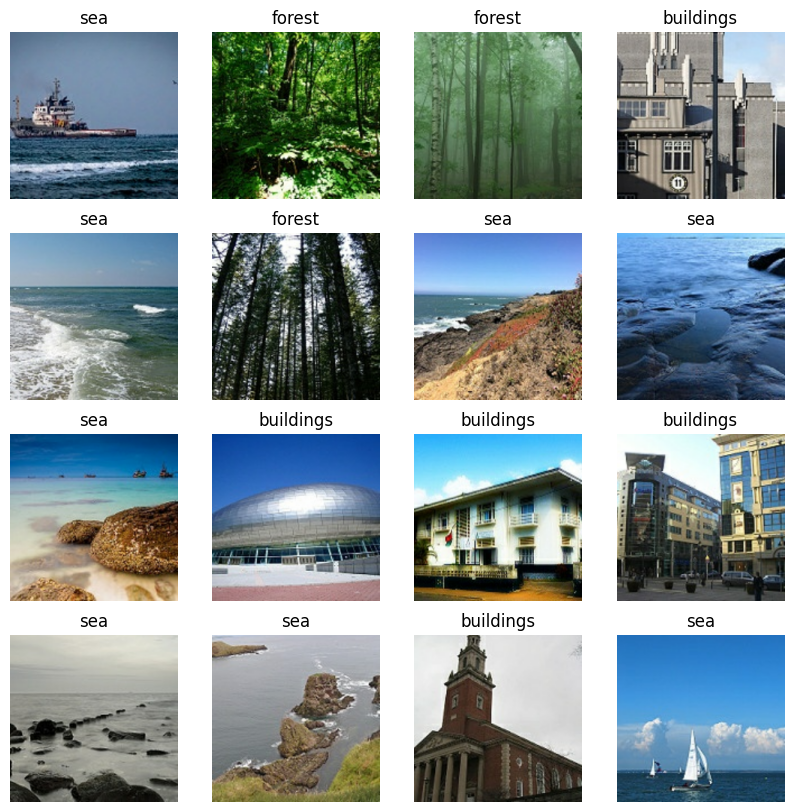

In [ ]:
import matplotlib.pyplot as plt

batch = next(iter(train))

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

label_map = {i: name for i, name in enumerate(class_names)}

for i, ax in enumerate(axes.flat):
    img = batch[0][i].numpy().astype("uint8")

    ax.imshow(img)

    label_idx = batch[1][i].numpy()
    ax.set_title(label_map[label_idx])

    ax.axis("off")

plt.show()

In [ ]:
train = train.prefetch(tf.data.AUTOTUNE)
val = val.prefetch(tf.data.AUTOTUNE)
test = test.prefetch(tf.data.AUTOTUNE)

In [ ]:
# build a model

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(224,224,3)),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# callbacks

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

In [ ]:
history = model.fit(
    train,
    validation_data=val,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 1063s 6s/step - accuracy: 0.5866 - loss: 0.8997 - val_accuracy: 0.7435 - val_loss: 0.6313 - learning_rate: 1.0000e-04
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.7368 - loss: 0.5923 - val_accuracy: 0.7835 - val_loss: 0.5213 - learning_rate: 1.0000e-04
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 139ms/step - accuracy: 0.7876 - loss: 0.5218 - val_accuracy: 0.7984 - val_loss: 0.4882 - learning_rate: 1.0000e-04
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - accuracy: 0.8090 - loss: 0.4834 - val_accuracy: 0.8065 - val_loss: 0.4643 - learning_rate: 1.0000e-04
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - accuracy: 0.8138 - loss: 0.4608 - val_accuracy: 0.8206 - val_loss: 0.4411 - learning_rate: 1.0000e-04
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.8283 - loss: 0.4378 - val_accuracy: 0.8273 - val_loss: 0.4236 - learning_rate: 1.0000e-04
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 143

In [ ]:
model.evaluate(test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 221s 5s/step - accuracy: 0.9106 - loss: 0.2766


[0.27660390734672546, 0.9106262922286987]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 906ms/step
Predicted: buildings (0.82)
Actual: buildings


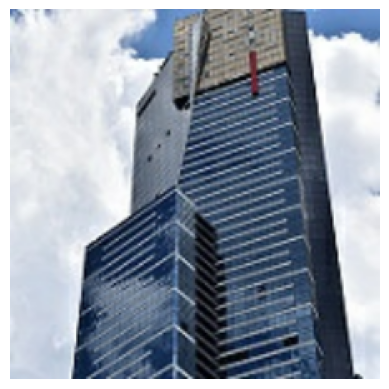

In [ ]:
import numpy as np

images, labels = next(iter(test))

img = images[0]
label = labels[0]

img_input = np.expand_dims(img, axis=0)

pred = model.predict(img_input)
pred_class = np.argmax(pred)
confidence = np.max(pred)

# display image
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")

print(f"Predicted: {class_names[pred_class]} ({confidence:.2f})")
print(f"Actual: {class_names[label.numpy()]}")

In [ ]:
print("Label index:", label.numpy())
print("Class:", class_names[label.numpy()])

Label index: 0
Class: buildings


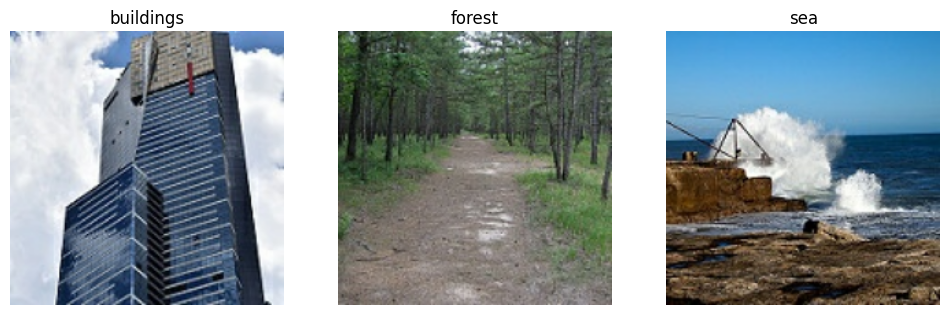

In [ ]:
# Show 1 image per class

import matplotlib.pyplot as plt

found = {0: None, 1: None, 2: None}  # store one image per class

# search dataset
for images, labels in test:
    for i in range(len(labels)):
        label = labels[i].numpy()

        if found[label] is None:
            found[label] = images[i].numpy().astype("uint8")

    # stop when all found
    if all(v is not None for v in found.values()):
        break

# display
fig, axes = plt.subplots(1, 3, figsize=(12,4))

for idx, ax in enumerate(axes):
    ax.imshow(found[idx])
    ax.set_title(class_names[idx])
    ax.axis("off")

plt.show()